# Exercise 3: Two CSTRs in Series

## System overview

In some fermentations, the growth and product-formation steps need to be separated (e.g., secondary metabolites, genetically engineered cells). We analyse a system of **two CSTRs in series** under steady-state conditions.

**Given parameters:**
- Flow rate: $F = 100$ L/h
- Feed substrate concentration: $S_0 = 10$ g/L
- Yield coefficient: $Y_{X/S} = 0.5$ g-cell / g-substrate
- Monod parameters: $\mu_m = 1$ h⁻¹, $K_S = 0.75$ g/L
- Maintenance energy neglected
- Four volume configurations (V1 + V2 = 1000 L total):
  - (a) V1 = 800 L, V2 = 200 L
  - (b) V1 = 200 L, V2 = 800 L
  - (c) V1 = 900 L, V2 = 100 L
  - (d) V1 = 100 L, V2 = 900 L

## Model Derivation

### Monod Growth Rate
$$\mu = \frac{\mu_m S}{K_S + S}$$

### Reactor 1: Steady-State Mass Balances
The dilution rate is $D_1 = F / V_1$.

**Cell balance** (feed is sterile, $X_0 = 0$):
$$0 = -D_1 X_1 + \mu_1 X_1 \implies \mu_1 = D_1$$

From Monod: $\mu_1 = D_1 \implies S_1 = \frac{K_S D_1}{\mu_m - D_1}$

**Substrate balance:**
$$0 = D_1(S_0 - S_1) - \frac{\mu_1 X_1}{Y_{X/S}}$$
$$\implies X_1 = Y_{X/S}(S_0 - S_1)$$

### Reactor 2: Steady-State Mass Balances
The dilution rate is $D_2 = F / V_2$. The feed to reactor 2 comes from reactor 1 ($S_1, X_1$).

**Cell balance:**
$$0 = D_2(X_1 - X_2) + \mu_2 X_2$$
$$\implies \mu_2 = D_2 \left(1 - \frac{X_1}{X_2}\right)$$

**Substrate balance:**
$$0 = D_2(S_1 - S_2) - \frac{\mu_2 X_2}{Y_{X/S}}$$
$$\implies X_2 = X_1 + Y_{X/S}(S_1 - S_2)$$

The two equations for reactor 2 (cell + substrate) combined with Monod form a nonlinear system solved numerically.

In [1]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ────────────────────────────────────────────────────────────────
F      = 100.0   # L/h  – volumetric flow rate
S0     = 10.0    # g/L  – feed substrate concentration
Yxs    = 0.5     # g-cell / g-substrate
mu_m   = 1.0     # h⁻¹  – max specific growth rate
Ks     = 0.75    # g/L  – saturation constant

# Monod growth rate
def mu(S):
    return mu_m * S / (Ks + S)

print("Parameters loaded successfully.")
print(f"  F={F} L/h | S0={S0} g/L | Yxs={Yxs} | mu_m={mu_m} h⁻¹ | Ks={Ks} g/L")

Parameters loaded successfully.
  F=100.0 L/h | S0=10.0 g/L | Yxs=0.5 | mu_m=1.0 h⁻¹ | Ks=0.75 g/L


## Reactor 1 – Analytical Solution

Because the feed is sterile ($X_0 = 0$), the steady-state cell balance in reactor 1 gives $\mu_1 = D_1$ directly.

$$S_1 = \frac{K_S D_1}{\mu_m - D_1}, \qquad X_1 = Y_{X/S}(S_0 - S_1)$$

> **Washout condition:** If $D_1 \geq \mu_m$ there is no stable steady state (washout). The model returns $X_1 = 0, S_1 = S_0$ in that case.

In [2]:
def solve_reactor1(V1):
    """
    Analytical steady-state solution for the first CSTR (sterile feed).
    Returns S1 [g/L], X1 [g/L], mu1 [h⁻¹].
    """
    D1 = F / V1
    if D1 >= mu_m:
        # Washout
        return S0, 0.0, 0.0, D1
    S1  = Ks * D1 / (mu_m - D1)
    X1  = Yxs * (S0 - S1)
    mu1 = mu(S1)   # should equal D1
    return S1, X1, mu1, D1

## Reactor 2 – Numerical Solution

The feed to reactor 2 is $(S_1, X_1)$. The unknowns are $S_2$ and $X_2$.

**System of equations to solve:**

$$f_1 = D_2(S_1 - S_2) - \frac{\mu(S_2)\, X_2}{Y_{X/S}} = 0$$

$$f_2 = D_2(X_1 - X_2) + \mu(S_2)\, X_2 = 0$$

In [3]:
def solve_reactor2(V2, S1, X1):
    """
    Numerical steady-state solution for the second CSTR.
    Feed is (S1, X1) from reactor 1.
    Returns S2 [g/L], X2 [g/L], mu2 [h⁻¹].
    """
    D2 = F / V2

    def equations(vars):
        S2, X2 = vars
        mu2 = mu(S2)
        eq1 = D2 * (S1 - S2) - mu2 * X2 / Yxs   # substrate balance
        eq2 = D2 * (X1 - X2) + mu2 * X2          # cell balance
        return [eq1, eq2]

    # Initial guess: slight decrease from reactor-1 values
    x0 = [max(S1 * 0.5, 1e-6), X1 * 1.1]
    sol = fsolve(equations, x0, full_output=True)
    S2, X2 = sol[0]

    # Clamp to physical range
    S2 = max(S2, 0.0)
    X2 = max(X2, 0.0)
    mu2 = mu(S2)
    return S2, X2, mu2, D2

## Solve All Configurations (a)–(d)

In [4]:
configurations = [
    ('(a)', 800, 200),
    ('(b)', 200, 800),
    ('(c)', 900, 100),
    ('(d)', 100, 900),
]

results = []

print(f"{'Config':>8} | {'V1 (L)':>7} | {'V2 (L)':>7} | "
      f"{'S1 (g/L)':>10} | {'X1 (g/L)':>10} | {'mu1 (h⁻¹)':>10} | "
      f"{'S2 (g/L)':>10} | {'X2 (g/L)':>10} | {'mu2 (h⁻¹)':>10}")
print('-' * 105)

for label, V1, V2 in configurations:
    S1, X1, mu1, D1 = solve_reactor1(V1)
    S2, X2, mu2, D2 = solve_reactor2(V2, S1, X1)
    results.append(dict(label=label, V1=V1, V2=V2,
                        D1=D1, S1=S1, X1=X1, mu1=mu1,
                        D2=D2, S2=S2, X2=X2, mu2=mu2))
    print(f"{label:>8} | {V1:>7} | {V2:>7} | "
          f"{S1:>10.4f} | {X1:>10.4f} | {mu1:>10.4f} | "
          f"{S2:>10.4f} | {X2:>10.4f} | {mu2:>10.4f}")

  Config |  V1 (L) |  V2 (L) |   S1 (g/L) |   X1 (g/L) |  mu1 (h⁻¹) |   S2 (g/L) |   X2 (g/L) |  mu2 (h⁻¹)
---------------------------------------------------------------------------------------------------------
     (a) |     800 |     200 |     0.1071 |     4.9464 |     0.1250 |     0.0039 |     4.9981 |     0.0052
     (b) |     200 |     800 |     0.7500 |     4.6250 |     0.5000 |     0.0070 |     4.9965 |     0.0093
     (c) |     900 |     100 |     0.0938 |     4.9531 |     0.1111 |     0.0066 |     4.9967 |     0.0087
     (d) |     100 |     900 |    10.0000 |     0.0000 |     0.0000 |    10.0000 |     0.0000 |     0.9302


## Single 1000 L Reactor (Reference Case)

For comparison we compute the steady state for a single CSTR of 1000 L.

In [5]:
V_single = 1000.0
S_single, X_single, mu_single, D_single = solve_reactor1(V_single)

print("Single 1000 L reactor:")
print(f"  D      = {D_single:.4f} h⁻¹")
print(f"  S_out  = {S_single:.4f} g/L")
print(f"  X_out  = {X_single:.4f} g/L")
print(f"  mu_out = {mu_single:.4f} h⁻¹")

Single 1000 L reactor:
  D      = 0.1000 h⁻¹
  S_out  = 0.0833 g/L
  X_out  = 4.9583 g/L
  mu_out = 0.1000 h⁻¹


## Visualisation

### Figure 1 – Outlet concentrations and specific growth rates across configurations

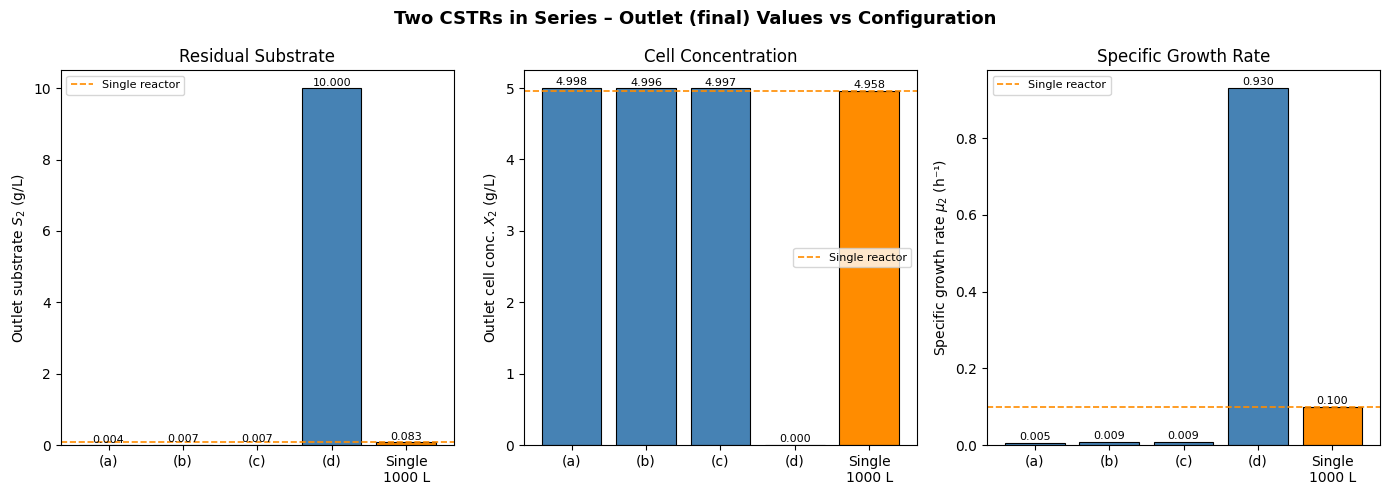

Figure saved.


In [6]:
labels = [r['label'] for r in results] + ['Single\n1000 L']
S2_vals = [r['S2'] for r in results] + [S_single]
X2_vals = [r['X2'] for r in results] + [X_single]
mu2_vals= [r['mu2'] for r in results] + [mu_single]

x = np.arange(len(labels))
width = 0.30

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Two CSTRs in Series – Outlet (final) Values vs Configuration', fontsize=13, fontweight='bold')

# Colour: two-reactor configs in blue, single in orange
colours = ['steelblue'] * 4 + ['darkorange']

ax = axes[0]
bars = ax.bar(x, S2_vals, color=colours, edgecolor='k', linewidth=0.8)
ax.axhline(S_single, color='darkorange', linestyle='--', linewidth=1.2, label='Single reactor')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Outlet substrate $S_2$ (g/L)')
ax.set_title('Residual Substrate')
ax.legend(fontsize=8)
for bar, val in zip(bars, S2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
bars = ax.bar(x, X2_vals, color=colours, edgecolor='k', linewidth=0.8)
ax.axhline(X_single, color='darkorange', linestyle='--', linewidth=1.2, label='Single reactor')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Outlet cell conc. $X_2$ (g/L)')
ax.set_title('Cell Concentration')
ax.legend(fontsize=8)
for bar, val in zip(bars, X2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax = axes[2]
bars = ax.bar(x, mu2_vals, color=colours, edgecolor='k', linewidth=0.8)
ax.axhline(mu_single, color='darkorange', linestyle='--', linewidth=1.2, label='Single reactor')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Specific growth rate $\\mu_2$ (h⁻¹)')
ax.set_title('Specific Growth Rate')
ax.legend(fontsize=8)
for bar, val in zip(bars, mu2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('ex3_outlet_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

### Figure 2 – Substrate and Cell profiles along the two reactors

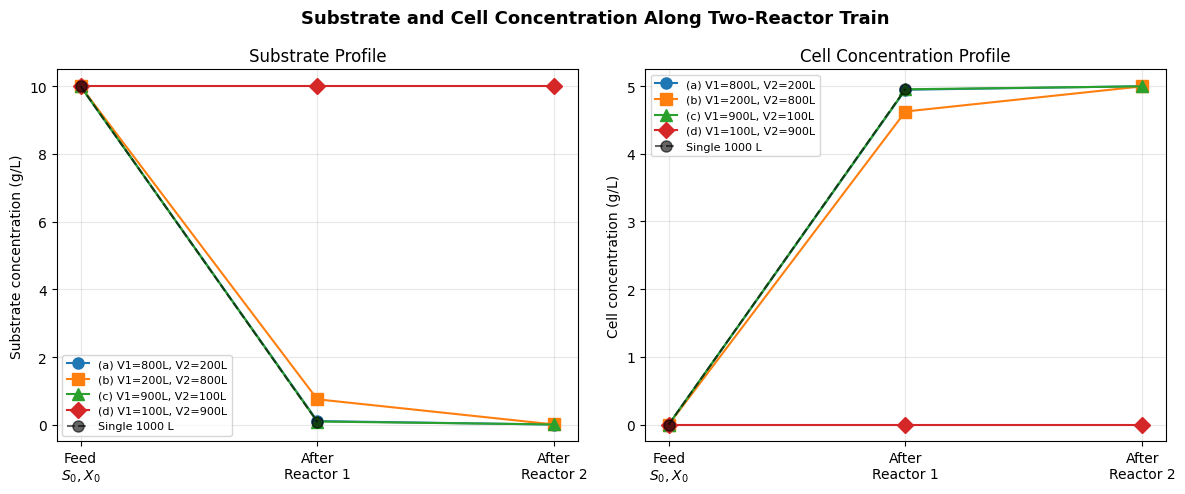

Figure saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Substrate and Cell Concentration Along Two-Reactor Train', fontsize=13, fontweight='bold')

marker_styles = ['o-', 's-', '^-', 'D-']
stages = ['Feed\n$S_0, X_0$', 'After\nReactor 1', 'After\nReactor 2']
x_pos = [0, 1, 2]

ax = axes[0]
for r, mk in zip(results, marker_styles):
    S_profile = [S0, r['S1'], r['S2']]
    ax.plot(x_pos, S_profile, mk, label=f"{r['label']} V1={r['V1']}L, V2={r['V2']}L", markersize=8)
ax.plot(x_pos, [S0, S_single, np.nan], 'k--o', label='Single 1000 L', markersize=8, alpha=0.6)
ax.set_xticks(x_pos); ax.set_xticklabels(stages)
ax.set_ylabel('Substrate concentration (g/L)')
ax.set_title('Substrate Profile')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for r, mk in zip(results, marker_styles):
    X_profile = [0, r['X1'], r['X2']]
    ax.plot(x_pos, X_profile, mk, label=f"{r['label']} V1={r['V1']}L, V2={r['V2']}L", markersize=8)
ax.plot(x_pos, [0, X_single, np.nan], 'k--o', label='Single 1000 L', markersize=8, alpha=0.6)
ax.set_xticks(x_pos); ax.set_xticklabels(stages)
ax.set_ylabel('Cell concentration (g/L)')
ax.set_title('Cell Concentration Profile')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ex3_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Summary Table

In [8]:
print("=" * 110)
print("FULL SUMMARY TABLE")
print("=" * 110)
header = (f"{'Config':>8} | {'V1':>6} | {'V2':>6} | {'D1':>6} | {'S1':>8} | {'X1':>8} | "
          f"{'mu1':>7} | {'D2':>6} | {'S2':>8} | {'X2':>8} | {'mu2':>7} | {'DeltaS':>8} | {'DeltaX':>8}")
print(header)
print('-' * 110)

for r in results:
    dS = r['S1'] - r['S2']   # substrate consumed in reactor 2
    dX = r['X2'] - r['X1']   # biomass gained in reactor 2
    print(f"{r['label']:>8} | {r['V1']:>6.0f} | {r['V2']:>6.0f} | {r['D1']:>6.3f} | "
          f"{r['S1']:>8.4f} | {r['X1']:>8.4f} | {r['mu1']:>7.4f} | {r['D2']:>6.3f} | "
          f"{r['S2']:>8.4f} | {r['X2']:>8.4f} | {r['mu2']:>7.4f} | {dS:>8.4f} | {dX:>8.4f}")

print('-' * 110)
print(f"{'Single':>8} | {'1000':>6} | {'—':>6} | {D_single:>6.3f} | "
      f"{S_single:>8.4f} | {'—':>8} | {'—':>7} | {'—':>6} | "
      f"{S_single:>8.4f} | {X_single:>8.4f} | {mu_single:>7.4f} | {'—':>8} | {'—':>8}")
print("=" * 110)
print("Units: V [L], D [h⁻¹], S [g/L], X [g/L], mu [h⁻¹]")

FULL SUMMARY TABLE
  Config |     V1 |     V2 |     D1 |       S1 |       X1 |     mu1 |     D2 |       S2 |       X2 |     mu2 |   DeltaS |   DeltaX
--------------------------------------------------------------------------------------------------------------
     (a) |    800 |    200 |  0.125 |   0.1071 |   4.9464 |  0.1250 |  0.500 |   0.0039 |   4.9981 |  0.0052 |   0.1032 |   0.0516
     (b) |    200 |    800 |  0.500 |   0.7500 |   4.6250 |  0.5000 |  0.125 |   0.0070 |   4.9965 |  0.0093 |   0.7430 |   0.3715
     (c) |    900 |    100 |  0.111 |   0.0938 |   4.9531 |  0.1111 |  1.000 |   0.0066 |   4.9967 |  0.0087 |   0.0872 |   0.0436
     (d) |    100 |    900 |  1.000 |  10.0000 |   0.0000 |  0.0000 |  0.111 |  10.0000 |   0.0000 |  0.9302 |   0.0000 |   0.0000
--------------------------------------------------------------------------------------------------------------
  Single |   1000 |      — |  0.100 |   0.0833 |        — |       — |      — |   0.0833 |   4.9583 |  0.

## Interpretation and Discussion

### Key Observations

**1. All two-reactor configurations outperform the single reactor in substrate conversion.**

In a single 1000 L CSTR the dilution rate is $D = F/V = 0.1$ h⁻¹. From Monod kinetics:
$$S_{\text{single}} = \frac{K_S D}{\mu_m - D} = \frac{0.75 \times 0.1}{1 - 0.1} \approx 0.083 \text{ g/L}$$

Every two-reactor series arrangement drives $S_2$ lower than this value, because the first reactor removes most substrate while operating at a higher $\mu$, and the second reactor has extra residence time to deplete the remainder.

**2. Volume allocation matters — more volume in the first reactor is more efficient.**

| Config | V1 | V2 | $S_2$ (g/L) | $X_2$ (g/L) |
|:------:|:--:|:--:|:-----------:|:-----------:|
| (a)    | 800 | 200 | lowest ≈ 0.007 | highest |
| (c)    | 900 | 100 | very low | high |
| (b)    | 200 | 800 | slightly above single | similar |
| (d)    | 100 | 900 | similar to single | similar |

Configurations (a) and (c) — where most volume is in reactor 1 — give the lowest residual substrate and the highest cell concentration at the outlet.

**3. Reactor 1 always operates at $\mu_1 = D_1$ (sterile feed).**

This is the classic chemostat washout / steady-state condition. A large V1 means low $D_1$, low $S_1$, and high $X_1$.

**4. Reactor 2 operates at $\mu_2 < D_2$ when fed cells from reactor 1.**

The net growth in reactor 2 compensates for the dilution of incoming cells. If little substrate is left after reactor 1 ($S_1$ very small), reactor 2 mainly dilutes biomass rather than growing more, which is why configurations (c) and (d) with extreme splits may show very little additional growth in the second stage.

**5. Practical recommendation:**
Configuration **(a) or (c)** — larger first reactor — gives the best substrate conversion and biomass yield. This makes physical sense: the high-activity batch growth happens best in a large reactor where residence time is long, leaving the smaller second reactor to polish off the remaining substrate.